## Problem Statement


Leveraging customer information is of paramount importance for most businesses. In the case of an insurance company, the attributes of customers can be crucial in making business decisions. Hence, knowing to explore and generate value out of such data can be an invaluable skill to have.

Suppose you are hired as a Data Scientist in an Insurance company. The company wants to have a detailed understanding of the customer base for one of its Insurance Policy 'MediClaim'. The idea is to generate insights about the customers and answer a few key questions with statistical evidence, by using the past dataset. The dataset 'AxisInsurance' contains customers' details like age, sex, charges, etc. Perform the statistical analysis to answer the following questions using the collected data.

1.	Explore the dataset and extract insights using Exploratory Data Analysis.

2.	Prove(or disprove) that the medical claims made by the people who smoke are greater than those who don't?

3.	Prove (or disprove) with statistical evidence that the BMI of females is different from that of males.

4.  Does the smoking habit of customers depend on their region?  [Hint: Create a contingency table using the pandas.crosstab() function]

5. Is the mean BMI of women with no children, one child, and two children the same? Explain your answer with statistical evidence.

The idea behind answering these questions is to help the company in making evidence-based business decisions.

## Assumptions
The Health Insurance Customer's data is a simple random sample from the population data, and the samples are independent of each other.

## Data Dictionary

**AxisInsurance.csv**  contains the following information about customers of the Axis Health Insurance.
1.	Age - This is an integer indicating the age of the primary beneficiary (excluding those above 64 years, since they are generally covered by the government).
2.	Sex - This is the policy holder's gender, either male or female.
3.	BMI - This is the body mass index (BMI), which provides a sense of how over or under-weight a person is relative to their height. BMI is equal to weight (in kilograms) divided by height (in meters) squared. An ideal BMI is within the range of 18.5 to 24.9.
4.	Children - This is an integer indicating the number of children / dependents covered by the insurance plan.
5.	Smoker - This is yes or no depending on whether the insured person regularly smokes tobacco.
6.	Region - This is the beneficiary's place of residence in the U.S., divided into four geographic regions - northeast, southeast, southwest, or northwest.
7.	Charges - Individual medical costs billed by health insurance

### Import all the necessary libraries

In [1]:
### Import Necessary Libraries

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.stats import (
    ttest_ind,
    chi2_contingency,
    f_oneway,
    shapiro,
    levene,
    norm
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# # Display settings
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", None)

# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1.	Explore the dataset and extract insights using Exploratory Data Analysis.

### Read the data into the notebook

In [17]:
# Loading the Axis Insurance Dataset
path = r"https://raw.githubusercontent.com/MonishDY/AI-Track/refs/heads/main/Capstone%20Project/AxisInsurance.csv"
data = pd.read_csv(path)

### View the first and last 5 rows of the dataset

In [18]:
# Read the first 5 rows of the dataset
data.head()

,age,sex,bmi,children,smoker,region,charges
0,21,female,16.000,1,no,northeast,3167.45585
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
# Read the last 5 rows of the dataset
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.54830
1334,52,female,46.75,5,no,southeast,12592.53450
1335,54,female,47.41,0,yes,southeast,63770.42801
1336,37,female,47.60,2,yes,southwest,46113.51100
1337,46,female,48.07,2,no,northeast,9432.92530


### Understand the shape of the dataset.

In [20]:
# Display the shape of the data
print("Shape of the Axis Insurance Dataset (row, column):", data.shape)

Shape of the Axis Insurance Dataset (row, column): (1338, 7)


### Check the data types of the columns for the dataset.

In [21]:
# Getting the info of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [22]:
# Display the data types of the columns
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


### Fixing the data types

In [23]:
# Identify categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns

print("Categorical columns:")
categorical_cols

Categorical columns:


Index(['sex', 'smoker', 'region'], dtype='object')

In [24]:
# Convert categorical columns to category data type
data[categorical_cols] = data[categorical_cols].astype('category')

# Verify the data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int64   
 1   sex       1338 non-null   category
 2   bmi       1338 non-null   float64 
 3   children  1338 non-null   int64   
 4   smoker    1338 non-null   category
 5   region    1338 non-null   category
 6   charges   1338 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 46.3 KB


In [26]:
# Identify numerical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

print("Numerical columns:")
numerical_cols

Numerical columns:


Index(['age', 'bmi', 'children', 'charges'], dtype='object')

### Check for missing values

In [25]:
# Check for missing values
missing_values = data.isnull().sum()

print("Missing values in each column:")
missing_values

Missing values in each column:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Five point summary of continuous variables

### Summary of categorical variables

In [28]:
# Check the number of unique values in each numerical column
for col in numerical_cols:
    print(f"{col}: {data[col].nunique()} unique values")

age: 47 unique values
bmi: 552 unique values
children: 6 unique values
charges: 1337 unique values


In [29]:
# Continuous and discrete variables
continuous_cols = ['age', 'bmi', 'charges']
discrete_cols = ['children']

print("Continuous variables:", continuous_cols)
print("Discrete variables:", discrete_cols)

Continuous variables: ['age', 'bmi', 'charges']
Discrete variables: ['children']


### Univariate analysis

In [39]:
# Statistical summary for numerical variables
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.682687,1.094918,13270.422265
std,14.049960,6.145674,1.205493,12110.011237
min,18.000000,14.000000,0.000000,1121.873900
25%,27.000000,26.315000,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.700000,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [40]:
# Statistical Summary for categorical variables
data.describe(include='category')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


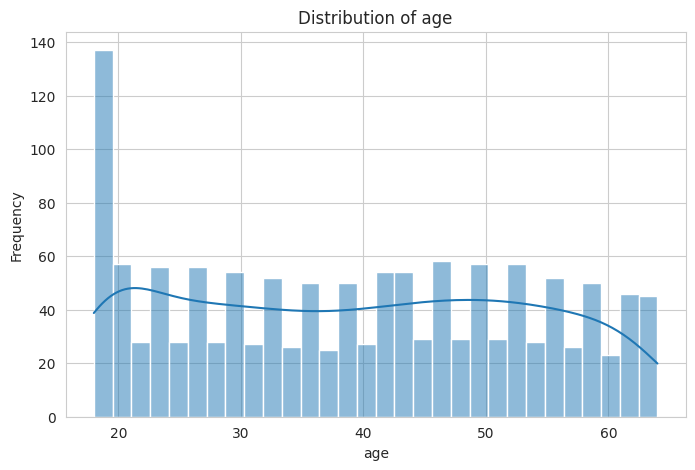

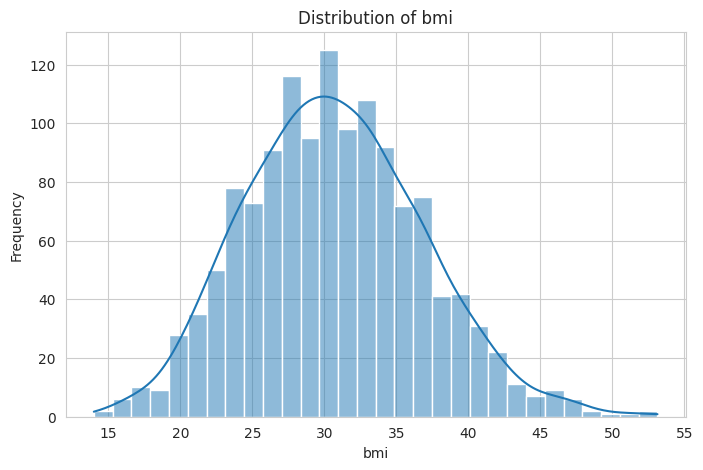

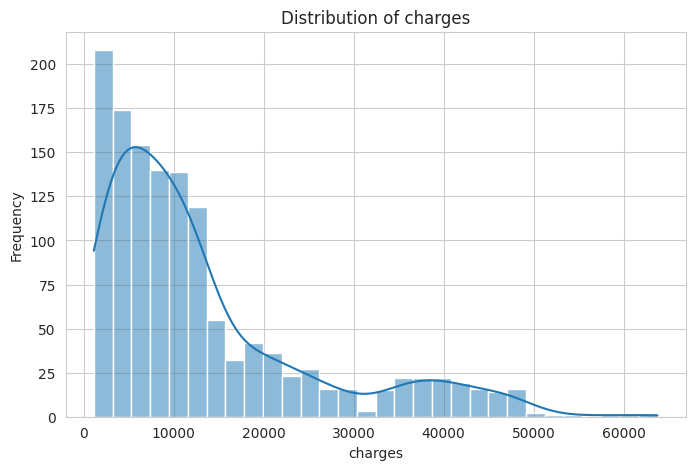

In [30]:
# Continuous variables
continuous_cols = ['age', 'bmi', 'charges']

for col in continuous_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

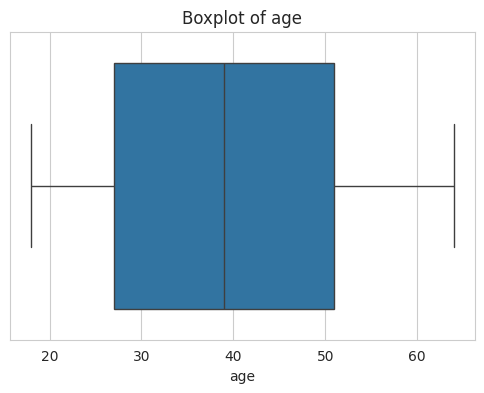

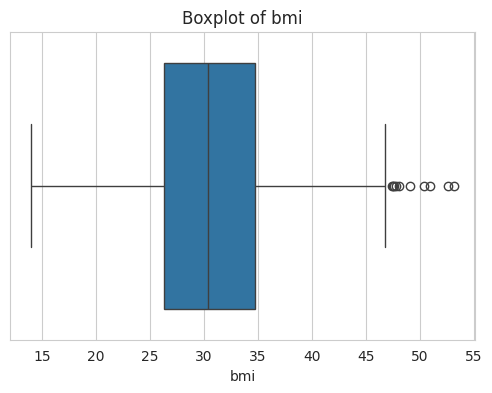

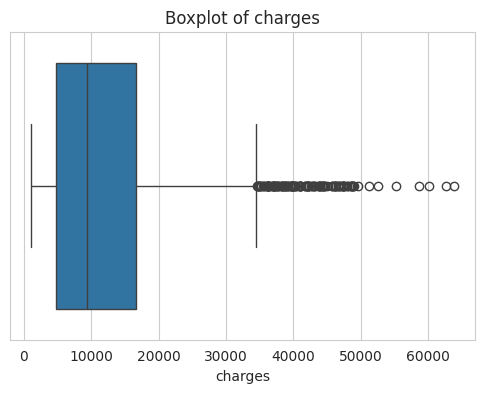

In [32]:
# Boxplots for continuous variables
for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

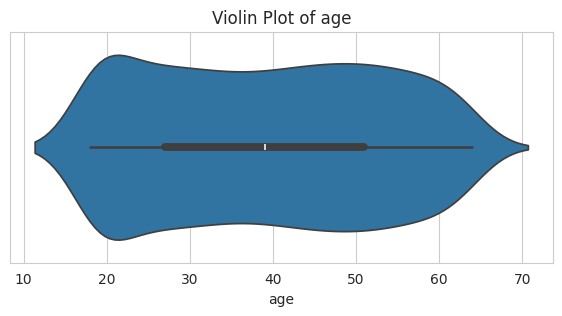

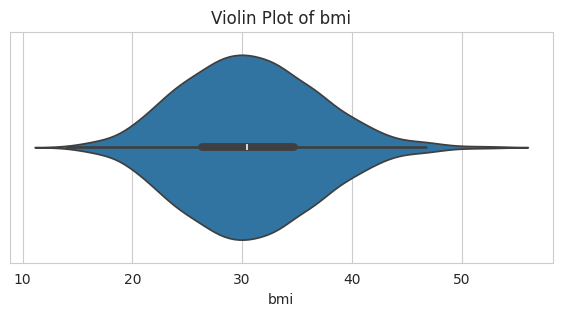

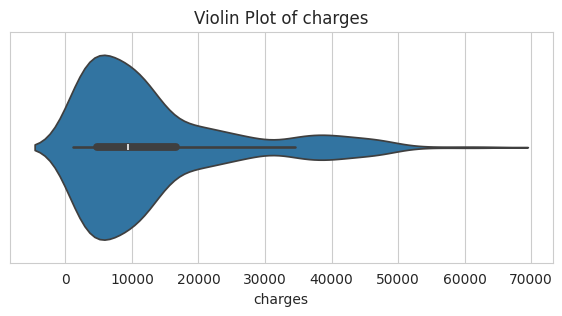

In [41]:
for col in continuous_cols:
    plt.figure(figsize=(7,3))
    sns.violinplot(x=data[col])
    plt.title(f'Violin Plot of {col}')
    plt.show()

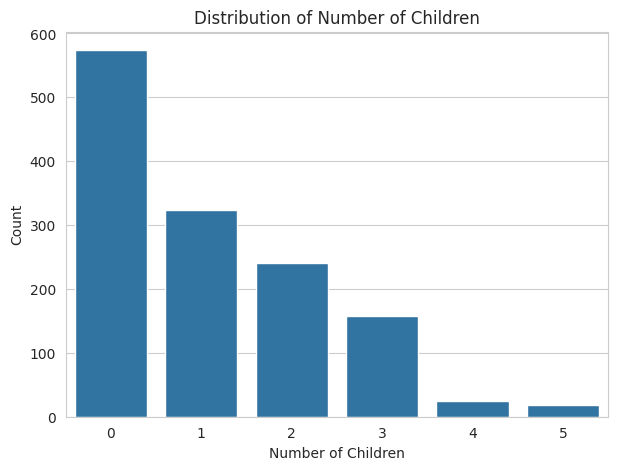

In [33]:
# Count plot for discrete variable
plt.figure(figsize=(7,5))
sns.countplot(x='children', data=data)
plt.title('Distribution of Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Count')
plt.show()

In [45]:
for col in categorical_cols:
    print(f"\nPercentage Distribution of {col}")
    print(data[col].value_counts())


Percentage Distribution of sex
sex
male      676
female    662
Name: count, dtype: int64

Percentage Distribution of smoker
smoker
no     1064
yes     274
Name: count, dtype: int64

Percentage Distribution of region
region
southeast    364
northwest    325
southwest    325
northeast    324
Name: count, dtype: int64


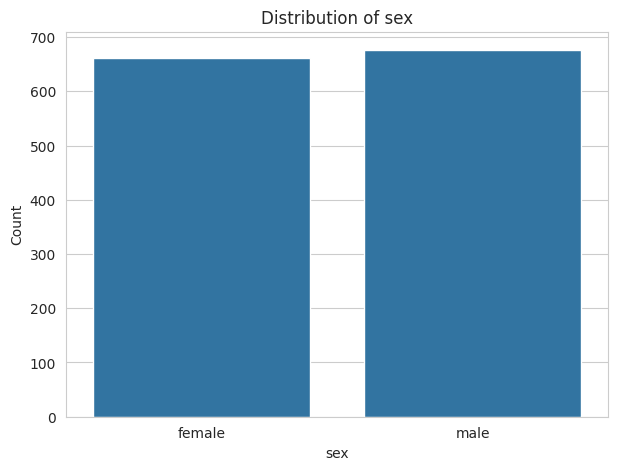

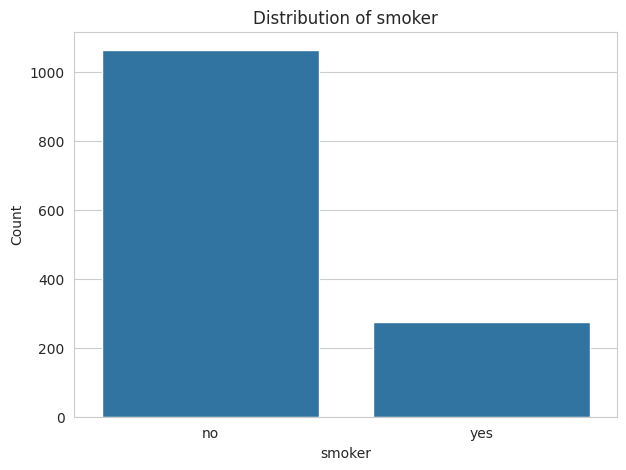

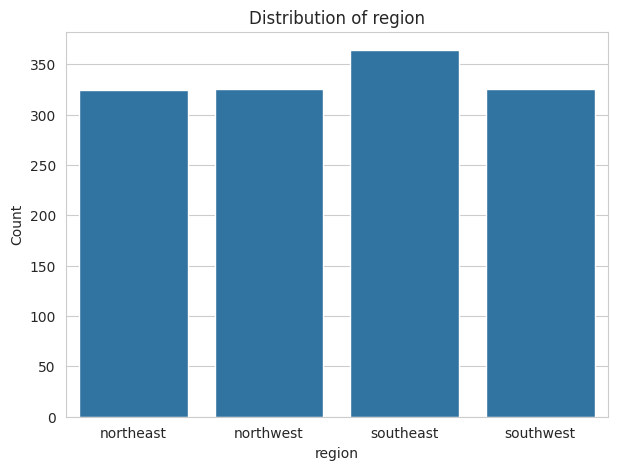

In [35]:
# Categorical variables
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    plt.figure(figsize=(7,5))
    sns.countplot(x=col, data=data)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [47]:
print(data[continuous_cols].skew())

age        0.055673
bmi        0.266910
charges    1.515880
dtype: float64


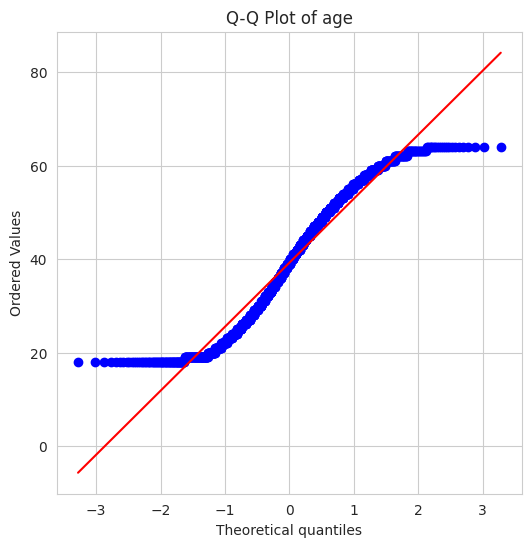

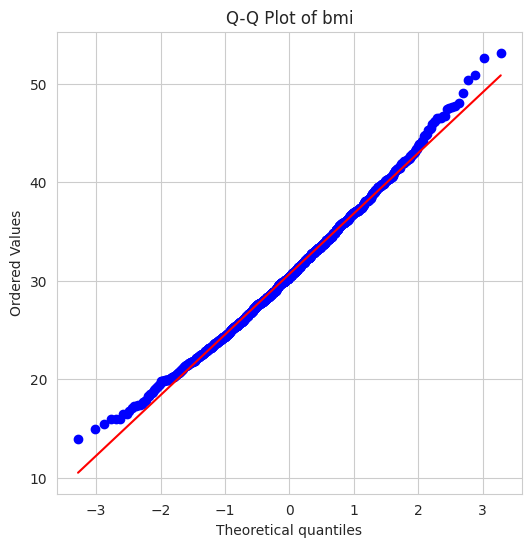

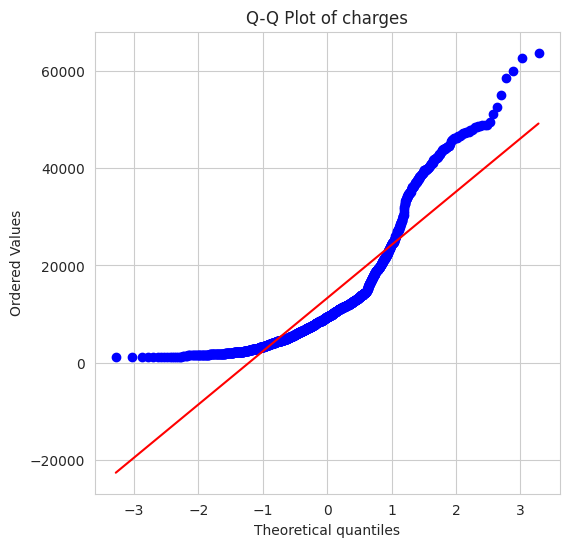

In [48]:
from scipy import stats

for col in continuous_cols:
    plt.figure(figsize=(6,6))
    stats.probplot(data[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')
    plt.show()

### Bivariate Analysis

## 2. Prove(or disprove)  that the medical claims made by the people who smoke is greater than those who don't?

### Step 1: Define the null and alternate hypotheses

### Step 2: Select Appropriate test

### Step 3: Decide the significance level

### Step 4: Collect and prepare data

### Step 5: Calculate the p-value

### Step 6: Compare the p-value with $\alpha$

### Step 7:  Draw inference

## 3. Prove (or disprove) with statistical evidence that BMI of females is different from that of males.

### Step 1: Define the null and alternate hypotheses

### Step 2: Select Appropriate test

### Step 3: Decide the significance level

### Step 4: Collect and prepare data

### Step 5: Calculate the p-value

### Step 6: Compare the p-value with $\alpha$

### Step 7:  Draw inference

## 4. Does the smoking habit of customers depend on their region?


### Step 1: Define the null and alternate hypotheses

### Step 2: Select Appropriate test

### Step 3: Decide the significance level

### Step 4: Collect and prepare data

### Step 5: Calculate the p-value

### Step 6: Compare the p-value with $\alpha$

### Step 7:  Draw inference

## 5.	Is the mean BMI of women with no children, one child and two children the same? Explain your answer with statistical evidence.

### Step 1: Define the null and alternate hypotheses

### Step 2: Select Appropriate test

### Shapiro-Wilk’s test

### Levene’s test

### Step 3: Decide the significance level

### Step 4: Collect and prepare data

### Step 5: Calculate the p-value

### Step 6: Compare the p-value with $\alpha$

### Step 7:  Draw inference

## Conclusion